In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["font.family"] = "Times New Roman"
matplotlib.rcParams["grid.alpha"] = 0.3  # Subtle grid
matplotlib.rcParams["axes.linewidth"] = 1.0  # 0.8  # Thinner axis lines
# matplotlib.rcParams["font.size"] = 14#8  # Base font size for publication
matplotlib.rcParams["axes.titlesize"] = 15  # 9
matplotlib.rcParams["axes.labelsize"] = 15  # 8

In [ ]:
dataset_path = "dim768_layer1_recur24_multiplier1.pth"
dataset = torch.load(dataset_path, weights_only=True)

In [ ]:
def plot_dataset(dataset, key="energy", it=None):
    fig_cfg = {
        "energy": ((1, 3), (12, 2)),
        "rank": ((2, 6), (18, 6)),
        "angle": ((2, 6), (18, 6)),
        "rank_angle": ((1, 2), (6, 2.5)),
    }
    if key not in fig_cfg:
        raise NotImplementedError
    (nrows, ncols), figsize = fig_cfg[key]
    fig, ax = plt.subplots(nrows, ncols, figsize=figsize)

    colors = {"effective_rank": "#0eb48d", "full_rank": "#0eb333", "angle": "#009ed7"}
    iters = [str(it)] if it is not None else ["24", "28", "32", "36", "40", "44", "48"]

    for i, it in enumerate(iters):
        data_it = dataset[it]

        if key == "energy":
            cmap = plt.get_cmap("plasma")
            is_extrap = int(it) > 24
            start_idx = max(0, int(it) - 5) if is_extrap else 0
            layers = np.arange(1, int(it) + 1)[start_idx:]
            color_it = 0.7 * ((int(it) - 24) / (48 - 24) - 1) + 0.7

            E_attn = data_it["energy_attn_traj"].detach().cpu().numpy()
            E_ff = data_it["energy_ff_traj"].detach().cpu().numpy()
            titles = ["Attention Module", "FeedForward Module", "Attention + FeedForward"]
            for j, (E_data, title) in enumerate(zip([E_attn, E_ff, E_attn + E_ff], titles)):
                E_mean = np.mean(E_data, axis=0)[start_idx:]
                E_std = np.std(E_data, axis=0)[start_idx:]
                ax[j].plot(layers, E_mean, "o-", markersize=4, color=cmap(color_it))
                ax[j].fill_between(layers, E_mean - E_std, E_mean + E_std, color=cmap(color_it),
                                   alpha=0.3, label=f"Iter {it}{' (Extrap.)' if is_extrap else ''}")
                ax[j].set_title(title, fontsize=14)
                ax[j].grid(True)
                ax[j].ticklabel_format(axis="y", style="sci", scilimits=(4, 4))
            fig.supylabel("Energy", fontsize=14)

        elif key == "rank":
            effective_rank = data_it["effective_rank"].detach().cpu().numpy()
            rank = data_it["rank"].detach().cpu().numpy()
            layers = np.arange(1, int(it) + 1)
            for h, a in enumerate(ax.flatten()):
                a.errorbar(layers, np.mean(effective_rank[:, h, :], axis=0),
                           np.std(effective_rank[:, h, :], axis=0),
                           fmt="s-", capsize=2, label="Effective Rank",
                           color=colors["effective_rank"], markersize=5, linewidth=1.0, elinewidth=0.5)
                a.errorbar(layers, np.mean(rank[:, h, :], axis=0),
                           np.std(rank[:, h, :], axis=0),
                           fmt="^-", capsize=2, label="Full Rank",
                           color=colors["full_rank"], markersize=5, linewidth=1.0, elinewidth=0.5)
                a.set(xlabel="Forward Iterations", ylabel="Effective/Full Rank", title=f"Head {h + 1}")
                a.legend(loc="best")
                a.grid(True)

        elif key == "angle":
            average_angle = data_it["average_angle"].detach().cpu().numpy()
            layers = np.arange(1, int(it) + 1)
            for h, a in enumerate(ax.flatten()):
                a.errorbar(layers, np.mean(average_angle[:, h, :], axis=0),
                           np.std(average_angle[:, h, :], axis=0),
                           fmt="D-", capsize=2, label="Average Angle",
                           color=colors["angle"], markersize=5, linewidth=1.0, elinewidth=0.8)
                a.set(xlabel="Forward Iterations", ylabel=r"Average Angle ($^\circ$)", title=f"Head {h + 1}")
                a.grid(True)

        elif key == "rank_angle":
            h = 3
            effective_rank = data_it["effective_rank"].detach().cpu().numpy()
            rank = data_it["rank"].detach().cpu().numpy()
            average_angle = data_it["average_angle"].detach().cpu().numpy()
            layers = np.arange(1, int(it) + 1)
            ax_flat = ax.flatten()

            ax_flat[0].errorbar(layers, np.mean(effective_rank[:, h, :], axis=0),
                                np.std(effective_rank[:, h, :], axis=0),
                                fmt="s-", capsize=3, label="Effective Rank",
                                color=colors["effective_rank"], markersize=5, linewidth=1.0, elinewidth=0.5)
            ax_flat[0].errorbar(layers, np.mean(rank[:, h, :], axis=0),
                                np.std(rank[:, h, :], axis=0),
                                fmt="^-", capsize=3, label="Full Rank",
                                color=colors["full_rank"], markersize=5, linewidth=1.0, elinewidth=0.5)
            ax_flat[0].set(xlabel="Forward Iterations", ylabel="Effective/Full Rank", title=f"Head {h + 1}")
            ax_flat[0].legend(loc="best", frameon=True)
            ax_flat[0].grid(True)

            ax_flat[1].errorbar(layers, np.mean(average_angle[:, h, :], axis=0),
                                np.std(average_angle[:, h, :], axis=0),
                                fmt="D-", capsize=2, label="Average Angle",
                                color=colors["angle"], markersize=5, linewidth=1.0, elinewidth=0.5)
            ax_flat[1].set(xlabel="Forward Iterations", ylabel=r"Average Angle ($^\circ$)", title=f"Head {h + 1}")
            ax_flat[1].legend(loc="best", frameon=True)
            ax_flat[1].grid(True)

    if key == "energy":
        handles, labels = [], []
        for axis in ax:
            h, l = axis.get_legend_handles_labels()
            handles.extend(h); labels.extend(l)
        unique_labels = dict(zip(labels, handles))
        fig.legend(unique_labels.values(), unique_labels.keys(),
                   loc="upper center", bbox_to_anchor=(0.52, 1.1), ncol=7, fontsize=10)

        acc = [0.0] * 7 + [
            0.1, 0.3, 2.4, 5.7, 12.2, 18.8, 24.1, 30.0, 35.0, 39.2, 42.3, 45.4, 48.7,
            50.7, 52.7, 54.2, 54.8, 55.5, 55.9, 56.2, 56.6, 56.7, 56.8, 56.8, 57.0,
            57.0, 57.0, 57.1, 57.1, 57.1, 57.1, 57.2, 57.2, 57.3, 57.3, 57.3, 57.3,
            57.4, 57.4, 57.4, 57.4,
        ]
        assert len(acc) == 48
        ax2 = ax[2].twinx()
        (acc_line,) = ax2.plot(np.arange(1, 49), acc, "o-", markersize=4, label=r"Accuracy (\%)")
        acc_color = acc_line.get_color()
        ax2.set_ylabel(r"Board Accuracy (\%)", fontsize=10, color=acc_color)
        ax2.tick_params(axis="y", colors=acc_color)
        ax2.set_ylim(0, 60)
        ax2.spines["right"].set_color(acc_color)
        ax2.spines["right"].set_linewidth(1.5)
        ax2.spines["top"].set_visible(False)

    for a in (ax.flatten() if isinstance(ax, np.ndarray) else [ax]):
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    kw = {"w_pad": 0.7, "h_pad": 0.2} if key == "energy" else {"pad": 0.5, "w_pad": 0.5, "h_pad": 0.5}
    plt.tight_layout(**kw)
    fig.patch.set_facecolor("white")
    # plt.savefig(f"{key}_sudoku_with_acc.pdf", bbox_inches="tight", dpi=300)
    plt.show()


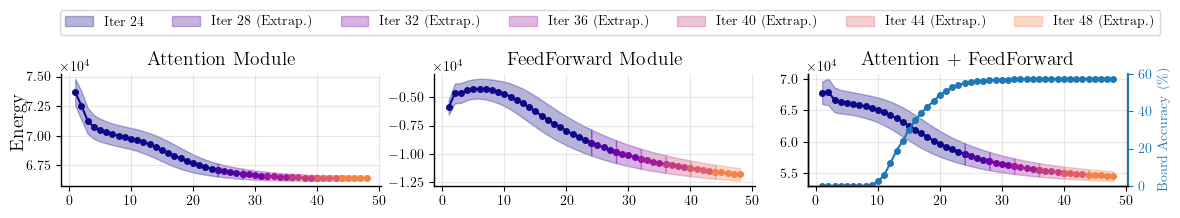

In [4]:
plot_dataset(dataset, "energy")

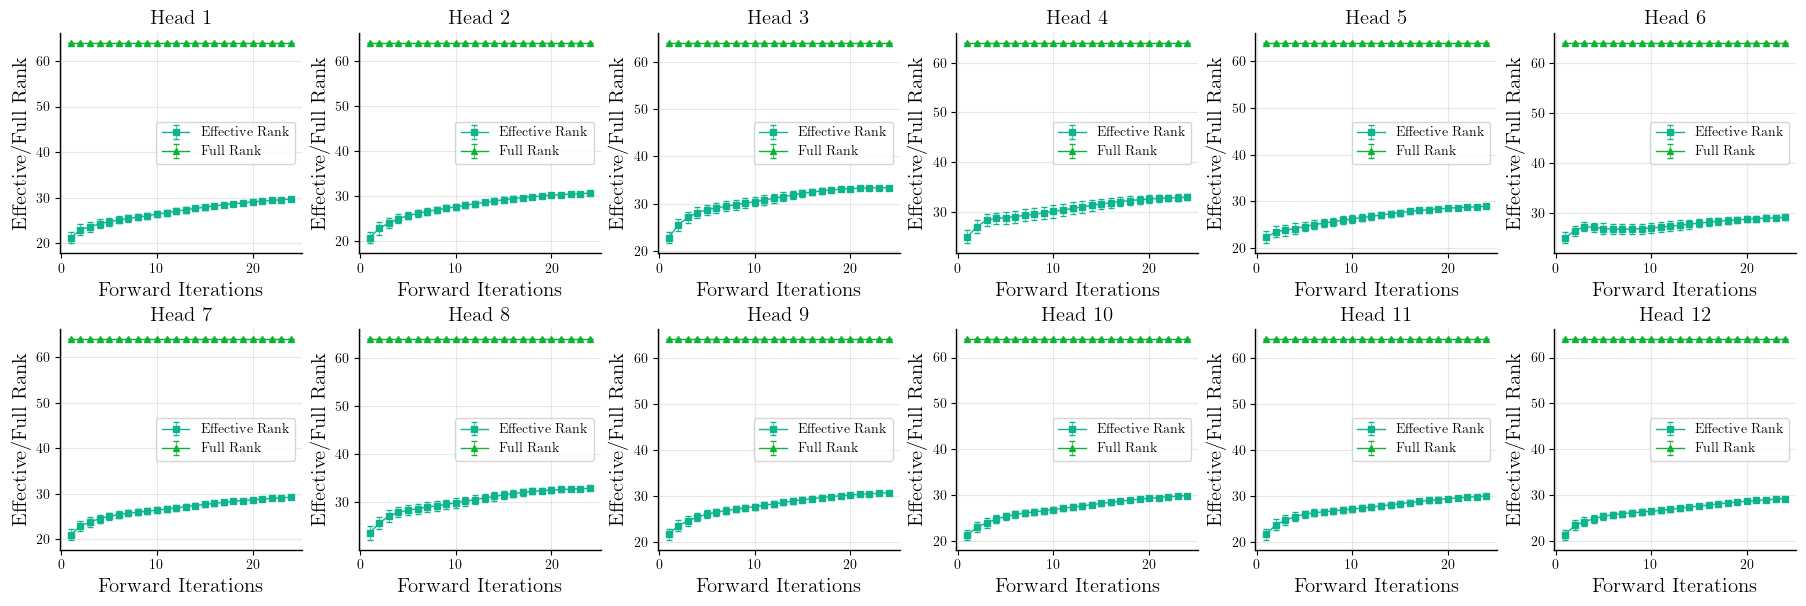

In [5]:
plot_dataset(dataset, "rank", 24)

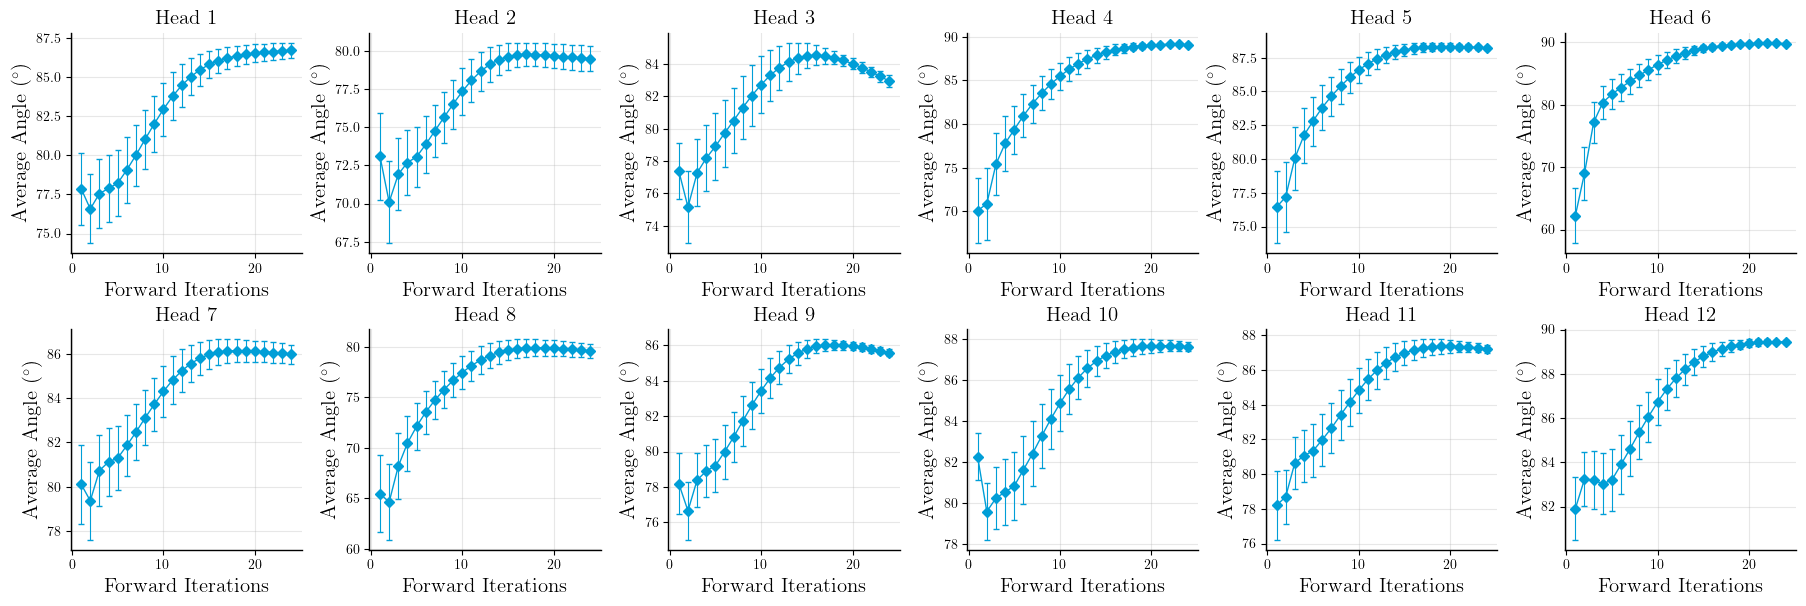

In [6]:
plot_dataset(dataset, "angle", 24)

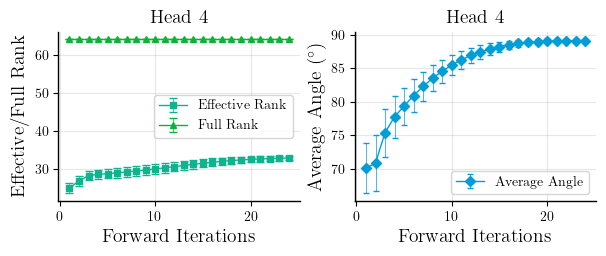

In [7]:
plot_dataset(dataset, "rank_angle", 24)